In [7]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [5]:
import pandas as pd

#Load the metadata
metadata = pd.read_csv("../../data/annotated_metadata.csv")
metadata.head(5)

#Exploration and analysis (distribution, missing values, etc...)

,Unnamed: 0.1,Unnamed: 0,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,...,grew,hurt,changed,bleed,elevation,img_id,biopsed,group_id,hairiness,marker
0,37,38,PAT_1431,1495,NaN,NaN,NaN,NaN,58,NaN,...,False,False,False,False,False,PAT_1431_1495_511.png,False,A,1,0
1,61,63,PAT_2051,4356,NaN,NaN,NaN,NaN,58,NaN,...,False,False,False,False,False,PAT_2051_4356_460.png,False,A,1,1
2,70,72,PAT_1255,876,NaN,NaN,NaN,NaN,60,NaN,...,True,False,False,False,False,PAT_1255_876_939.png,False,A,0,0
3,79,81,PAT_963,1820,False,True,ITALY,GERMANY,58,True,...,False,False,False,False,False,PAT_963_1820_823.png,True,A,1,0
4,94,96,PAT_419,832,False,False,POMERANIA,POMERANIA,80,False,...,False,True,False,True,True,PAT_419_832_706.png,True,A,0,1


In [11]:
metadata.shape

(117, 31)

vil gerne have kode der kan fordele alle billeder efter hairiness annotation og plotte det.

Derefter vil jeg gerne lave et plot hvor at man kan se fordelingen af de forskellige annotations med hairiness functionen.

Plot hairiness value in color depending on hairiness annotation.

In [8]:
def hair_coverage(img_gray):

    # generate hair mask using BlackHat filtering
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
    blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    total_area = img_gray.shape[0] * img_gray.shape[1]
    hair_area = np.sum(hair_mask > 0)
    coverage = hair_area / total_area
    
    return round(coverage, 4)

In [ ]:
metadata["coverage_hair"] = 0

In [26]:
for i in range(metadata.shape[0]):
    img_id = metadata["img_id"][i]
    img_path = (f"../../data/group_data/imgs/{img_id}")

    img_org_hair = cv2.imread(img_path)
    img_gray_hair = cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2GRAY)

    coverage_hair = hair_coverage(img_gray_hair)
    metadata.loc[i, "coverage_hair"] = coverage_hair

In [28]:
metadata.head(20)

,Unnamed: 0.1,Unnamed: 0,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,...,hurt,changed,bleed,elevation,img_id,biopsed,group_id,hairiness,marker,coverage_hair
0,37,38,PAT_1431,1495,NaN,NaN,NaN,NaN,58,NaN,...,False,False,False,False,PAT_1431_1495_511.png,False,A,1,0,0.0005
1,61,63,PAT_2051,4356,NaN,NaN,NaN,NaN,58,NaN,...,False,False,False,False,PAT_2051_4356_460.png,False,A,1,1,0.0076
2,70,72,PAT_1255,876,NaN,NaN,NaN,NaN,60,NaN,...,False,False,False,False,PAT_1255_876_939.png,False,A,0,0,0.0008
3,79,81,PAT_963,1820,False,True,ITALY,GERMANY,58,True,...,False,False,False,False,PAT_963_1820_823.png,True,A,1,0,0.0010
4,94,96,PAT_419,832,False,False,POMERANIA,POMERANIA,80,False,...,True,False,True,True,PAT_419_832_706.png,True,A,0,1,0.0007
5,158,162,PAT_655,926,False,False,GERMANY,GERMANY,53,False,...,False,False,False,False,PAT_655_926_447.png,False,A,1,0,0.0002
6,162,166,PAT_1701,3135,NaN,NaN,NaN,NaN,75,NaN,...,False,False,False,True,PAT_1701_3135_5.png,False,A,2,0,0.0052
7,164,168,PAT_216,331,True,True,POMERANIA,POMERANIA,71,True,...,False,False,False,False,PAT_216_331_678.png,True,A,1,0,0.0805
8,178,182,PAT_985,1856,False,False,POMERANIA,POMERANIA,49,True,...,True,False,True,True,PAT_985_1856_397.png,True,A,0,0,0.0035
9,189,193,PAT_1089,375,NaN,NaN,NaN,NaN,39,NaN,...,False,False,False,True,PAT_1089_375_677.png,False,A,1,0,0.0078


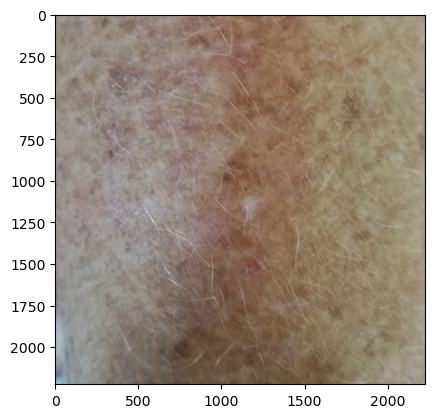

In [20]:
img_id = metadata["img_id"][0]
img_path = (f"../../data/group_data/imgs/{img_id}")

img_org_hair = cv2.imread(img_path)

img_gray_hair = cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2GRAY)

plt.imshow(cv2.cvtColor(img_org_hair, cv2.COLOR_BGR2RGB))

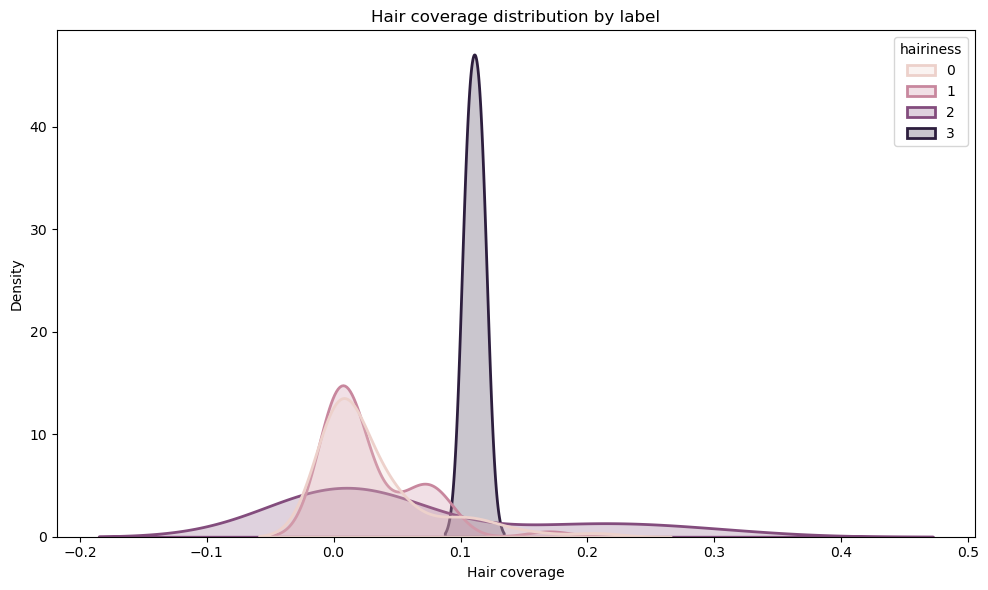

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=metadata,
    x="coverage_hair",
    hue="hairiness",          
    fill=True,
    common_norm=False,
    linewidth=2
)

plt.xlabel("Hair coverage")
plt.ylabel("Density")
plt.title("Hair coverage distribution by label")

plt.tight_layout()
plt.show()
